# CSE 144 Final Project – Transfer Learning Challenge
**Spring 2026 | UC Santa Cruz**

This notebook trains a transfer-learning classifier on the 100-class Kaggle dataset and generates `submission.csv`.

## 0. Setup & Imports

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Configuration

Mounting my Google Drive with the Kaggle Data uploaded.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ln -s "/content/drive/My Drive/data" "/content/data"

Mounted at /content/drive


In [ ]:
from pathlib import Path
# Paths
DATA_ROOT   = Path("/content/data")
TRAIN_DIR   = DATA_ROOT / "train"
TEST_DIR    = DATA_ROOT / "test"
OUTPUT_CSV  = Path("submission.csv")
WEIGHTS_OUT = Path("best_model.pth")
SAMPLE_CSV  = DATA_ROOT / "sample_submission.csv"

# Hyperparameters
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 100
VAL_FRACTION   = 0.15

# Phase 1: head-only training (backbone frozen)
PHASE1_EPOCHS  = 10
PHASE1_LR      = 3e-3

# Phase 2: full fine-tune (all layers unfrozen)
PHASE2_EPOCHS  = 40
HEAD_LR        = 1e-3
BACKBONE_LR    = 1e-4

WEIGHT_DECAY   = 1e-4
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA    = 0.4
PATIENCE       = 12

## 4. Fix Label Folder Names
`ImageFolder` sorts alphabetically so `'10' < '2'`. Zero-padding fixes this.

In [ ]:
renamed = 0
for name in os.listdir(TRAIN_DIR):
    try:
        n = int(name)
        padded = f'{n:02d}'
        if name != padded:
            src, dst = TRAIN_DIR / name, TRAIN_DIR / padded
            if not dst.exists():
                os.rename(src, dst)
                renamed += 1
    except ValueError:
        pass
print(f'Renamed {renamed} folders.')
folders = sorted(os.listdir(TRAIN_DIR))
expected = [f'{i:02d}' for i in range(100)]
assert folders == expected, f'Unexpected folder names: {folders[:5]}'
print('Folder names verified: 00 → 99 ✓')

Renamed 0 folders.
Folder names verified: 00 → 99 ✓


## 2. Data Loading & Augmentation

In [ ]:
# Mixup Helper
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
import os
from pathlib import Path

if not TRAIN_DIR.is_dir():
    print(f"Error: {TRAIN_DIR} does not exist or is not a directory. Please check your DATA_ROOT and symbolic link setup.")
else:
    print(f"Renaming folders in {TRAIN_DIR}...")
    renamed_count = 0
    for folder_name in os.listdir(TRAIN_DIR):
        try:
            num_label = int(folder_name)
            new_folder_name = f"{num_label:02d}"

            if folder_name != new_folder_name:
                old_path = TRAIN_DIR / folder_name
                new_path = TRAIN_DIR / new_folder_name
                if not new_path.exists():
                    os.rename(old_path, new_path)
                    print(f"  Renamed '{folder_name}' to '{new_folder_name}'")
                    renamed_count += 1
                else:
                    print(f"  Warning: Target folder '{new_folder_name}' already exists. Skipping rename for '{folder_name}'.")
        except ValueError:
            pass
    print(f"Finished renaming. Total folders renamed: {renamed_count}")

    # print(f"\nNew contents of TRAIN_DIR ({TRAIN_DIR}) after renaming:")
    # !ls -1 "{TRAIN_DIR}"

Renaming folders in /content/data/train...
Finished renaming. Total folders renamed: 0

New contents of TRAIN_DIR (/content/data/train) after renaming:
00
01
02
03
04
05
06
07
08
09
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [ ]:
# ImageNet normalization (used by all torchvision pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Stronger train augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Three TTA views: original, center-crop, horizontal flip
tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
]

full_dataset = ImageFolder(str(TRAIN_DIR), transform=train_transform)
n_val   = int(len(full_dataset) * VAL_FRACTION)
n_train = len(full_dataset) - n_val
gen = torch.Generator().manual_seed(SEED)
train_set, val_set = random_split(full_dataset, [n_train, n_val], generator=gen)

class ValSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        return self.transform(Image.open(path).convert('RGB')), label

val_dataset  = ValSubset(val_set, val_transform)
train_loader = DataLoader(train_set,   batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

class_to_idx = full_dataset.class_to_idx
print(f'Train: {n_train} | Val: {n_val} | Classes: {len(class_to_idx)}')
assert class_to_idx.get('00') == 0, 'Label mapping error — re-run folder rename cell!'
print('Label mapping: 00→0, 01→1, ... 99→99 ✓')

Train: 918 | Val: 161 | Classes: 100
Label mapping: 00→0, 01→1, ... 99→99 ✓


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3. Model – EfficientNet-B2 Backbone

In [ ]:
def build_model(num_classes=NUM_CLASSES):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

    # Freeze entire backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    # Head params are trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


def unfreeze_top_blocks(model, n_blocks=3):
    features = list(model.features.children())
    # features[-1] is the final conv, features[-2..] are MBConv blocks
    for block in features[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Unfroze last {n_blocks} blocks → {n_trainable:,} trainable params")


model = build_model()
model = model.to(DEVICE)
n_total = sum(p.numel() for p in model.parameters())
n_train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {n_total:,}  |  Trainable (phase 1): {n_train_p:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 180MB/s]


Total params: 11,534,476  |  Trainable (phase 1): 838,244


## 4. Training Utilities

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, use_mixup=True):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if use_mixup:
            imgs, y_a, y_b, lam = mixup_data(imgs, labels)
            outputs = model(imgs)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total

## 5. Phase 1 – Train Head Only (Backbone Frozen)

In [ ]:
# Label smoothing reduces overconfident predictions
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Only head params
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("=== Phase 1: Head-only training ===")
for epoch in range(1, PHASE1_EPOCHS + 1):
    tl, ta = train_one_epoch(model, train_loader, optimizer_p1, criterion, use_mixup=True)
    vl, va = evaluate(model, val_loader, criterion)
    scheduler_p1.step()
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)
    print(f"  Ep {epoch:02d}/{PHASE1_EPOCHS} | "
          f"T-Loss {tl:.3f} T-Acc {ta:.3f} | "
          f"V-Loss {vl:.3f} V-Acc {va:.3f}")

=== Phase 1: Head-only training ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Ep 01/10 | T-Loss 4.377 T-Acc 0.041 | V-Loss 3.820 V-Acc 0.143
  Ep 02/10 | T-Loss 3.674 T-Acc 0.120 | V-Loss 3.270 V-Acc 0.236
  Ep 03/10 | T-Loss 3.340 T-Acc 0.167 | V-Loss 3.031 V-Acc 0.286
  Ep 04/10 | T-Loss 3.287 T-Acc 0.176 | V-Loss 2.960 V-Acc 0.317
  Ep 05/10 | T-Loss 3.187 T-Acc 0.200 | V-Loss 2.905 V-Acc 0.317
  Ep 06/10 | T-Loss 2.919 T-Acc 0.209 | V-Loss 2.826 V-Acc 0.342
  Ep 07/10 | T-Loss 2.758 T-Acc 0.139 | V-Loss 2.787 V-Acc 0.329
  Ep 08/10 | T-Loss 2.930 T-Acc 0.346 | V-Loss 2.762 V-Acc 0.329
  Ep 09/10 | T-Loss 2.951 T-Acc 0.227 | V-Loss 2.796 V-Acc 0.366
  Ep 10/10 | T-Loss 2.811 T-Acc 0.205 | V-Loss 2.784 V-Acc 0.329


## 6. Phase 2 – Fine-Tune Full Network

In [ ]:
# Unfreeze top 4 blocks of EfficientNet features
print("\n=== Phase 2: Fine-tuning with differential LRs ===")
unfreeze_top_blocks(model, n_blocks=4)

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and "classifier" not in n]
head_params     = list(model.classifier.parameters())

optimizer_p2 = optim.AdamW([
    {"params": backbone_params, "lr": BACKBONE_LR},
    {"params": head_params,     "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=10, T_mult=1, eta_min=1e-6
)

best_val_acc  = max(history["val_acc"], default=0.)
no_improve    = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    # Gradually unfreeze more blocks mid-phase
    if epoch == 10:
        print("  [Unfreezing 2 more blocks]")
        unfreeze_top_blocks(model, n_blocks=6)
        # Add newly unfrozen params to optimizer
        new_backbone = [p for n, p in model.named_parameters()
                        if p.requires_grad and "classifier" not in n
                        and not any(p is ep for g in optimizer_p2.param_groups for ep in g["params"])]
        if new_backbone:
            optimizer_p2.add_param_group({"params": new_backbone, "lr": BACKBONE_LR * 0.5})
            # Re-initialize the scheduler to account for the new parameter group
            # This might reset the cosine annealing cycle for all groups, which is a trade-off.
            scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer_p2, T_0=10, T_mult=1, eta_min=1e-6
            )
            # Set last_epoch to ensure the scheduler continues from the correct point
            scheduler_p2.last_epoch = epoch - 1
            print(f"  Scheduler re-initialized at epoch {epoch}")

    tl, ta = train_one_epoch(model, train_loader, optimizer_p2, criterion, use_mixup=True)
    vl, va = evaluate(model, val_loader, criterion)
    scheduler_p2.step()

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    print(f"  Ep {epoch:02d}/{PHASE2_EPOCHS} | "
          f"T-Loss {tl:.3f} T-Acc {ta:.3f} | "
          f"V-Loss {vl:.3f} V-Acc {va:.3f}", end="")

    if va > best_val_acc:
        best_val_acc = va
        no_improve   = 0
        torch.save(model.state_dict(), WEIGHTS_OUT)
        print("  ← best saved")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("  Early stopping triggered.")
            break

print(f"\nBest val accuracy: {best_val_acc:.4f}")


=== Phase 2: Fine-tuning with differential LRs ===
  Unfroze last 4 blocks → 10,732,082 trainable params
  Ep 01/40 | T-Loss 2.900 T-Acc 0.157 | V-Loss 2.734 V-Acc 0.342  (no improve 1/12)
  Ep 02/40 | T-Loss 2.822 T-Acc 0.218 | V-Loss 2.675 V-Acc 0.391  ← best saved
  Ep 03/40 | T-Loss 2.606 T-Acc 0.251 | V-Loss 2.571 V-Acc 0.422  ← best saved
  Ep 04/40 | T-Loss 2.513 T-Acc 0.284 | V-Loss 2.524 V-Acc 0.422  (no improve 1/12)
  Ep 05/40 | T-Loss 2.511 T-Acc 0.327 | V-Loss 2.463 V-Acc 0.478  ← best saved
  Ep 06/40 | T-Loss 2.516 T-Acc 0.370 | V-Loss 2.472 V-Acc 0.460  (no improve 1/12)
  Ep 07/40 | T-Loss 2.503 T-Acc 0.383 | V-Loss 2.450 V-Acc 0.503  ← best saved
  Ep 08/40 | T-Loss 2.266 T-Acc 0.443 | V-Loss 2.421 V-Acc 0.491  (no improve 1/12)
  Ep 09/40 | T-Loss 2.311 T-Acc 0.285 | V-Loss 2.436 V-Acc 0.466  (no improve 2/12)
  [Unfreezing 2 more blocks]
  Unfroze last 6 blocks → 11,481,694 trainable params
  Scheduler re-initialized at epoch 10
  Ep 10/40 | T-Loss 2.595 T-Acc 0.35

## 7. Training Curves

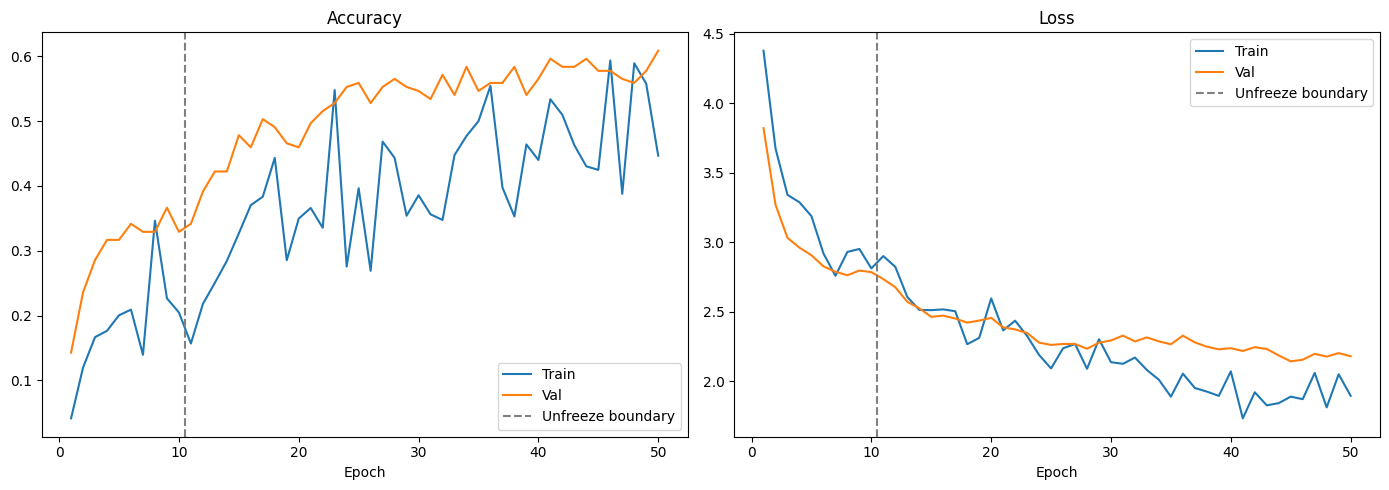

Saved training_curves.png


In [ ]:
epochs = range(1, len(history["train_acc"]) + 1)
unfreeze_ep = PHASE1_EPOCHS + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history["train_acc"], label="Train")
ax1.plot(epochs, history["val_acc"],   label="Val")
ax1.axvline(unfreeze_ep, ls="--", color="gray", label="Unfreeze boundary")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["train_loss"], label="Train")
ax2.plot(epochs, history["val_loss"],   label="Val")
ax2.axvline(unfreeze_ep, ls="--", color="gray", label="Unfreeze boundary")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

## 8. Inference & Test Time Augmentation

In [ ]:
class TestDataset(Dataset):
    def __init__(self, test_dir, transform):
        self.paths     = sorted(Path(test_dir).glob('*.jpg'), key=lambda p: int(p.stem))
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.transform(img), self.paths[i].name


@torch.no_grad()
def predict_tta(model, test_dir, tta_tfs, sample_csv_path):
    model.load_state_dict(torch.load(WEIGHTS_OUT, map_location=DEVICE))
    model.eval()

    all_probs = None
    all_ids   = None

    for tf in tta_tfs:
        loader = DataLoader(
            TestDataset(test_dir, tf),
            batch_size=BATCH_SIZE, shuffle=False, num_workers=4
        )
        probs_list, ids_list = [], []
        for imgs, ids in loader:
            logits = model(imgs.to(DEVICE))
            probs_list.append(torch.softmax(logits, dim=1).cpu())
            ids_list.extend(ids)
        batch_probs = torch.cat(probs_list, dim=0)
        all_probs   = batch_probs if all_probs is None else all_probs + batch_probs
        all_ids     = ids_list

    preds = all_probs.argmax(dim=1).numpy()

    # Build submission preserving sample CSV row order
    sample_df      = pd.read_csv(sample_csv_path)
    id_to_pred     = dict(zip(all_ids, preds.tolist()))
    sample_df['Label'] = sample_df['ID'].map(id_to_pred)

    # Sanity checks before saving
    n_null = sample_df['Label'].isnull().sum()
    assert n_null == 0, f'{n_null} unmapped IDs — ID format mismatch!'
    sample_df['Label'] = sample_df['Label'].astype(int)
    assert sample_df['Label'].between(0, 99).all(), 'Label out of range 0-99!'

    sample_df.to_csv(OUTPUT_CSV, index=False)
    print(f'Saved {OUTPUT_CSV} — {len(sample_df)} predictions')
    print(f'Label range: {sample_df["Label"].min()} – {sample_df["Label"].max()}')
    print(f'Unique labels: {sample_df["Label"].nunique()}')
    print(sample_df.head(10))
    return sample_df


sub = predict_tta(model, TEST_DIR, tta_transforms, SAMPLE_CSV)

Saved submission.csv — 1036 predictions
Label range: 0 – 99
Unique labels: 99
      ID  Label
0  0.jpg     66
1  1.jpg     43
2  2.jpg     38
3  3.jpg     62
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     49
8  8.jpg     62
9  9.jpg     66


In [ ]:
from google.colab import files
files.download(str(OUTPUT_CSV))
print('submission.csv download triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

submission.csv download triggered.


## 9. Verify Label Mapping

In [ ]:
print("class_to_idx sample:")
for k_int in [0, 1, 2, 50, 99]:
    k_str = f"{k_int:02d}"
    print(f"  folder '{k_str}' → label {class_to_idx[k_str]}")

# Sanity check: all labels 0..99 present in submission
label_counts = sub["Label"].value_counts().sort_index()
print(f"\nUnique labels in submission: {sub['Label'].nunique()}")
print(f"Label range: {sub['Label'].min()} – {sub['Label'].max()}")

class_to_idx sample:
  folder '00' → label 0
  folder '01' → label 1
  folder '02' → label 2
  folder '50' → label 50
  folder '99' → label 99

Unique labels in submission: 99
Label range: 0 – 99


## 10. Environment Info

In [ ]:
import torchvision, sys
print("Python     :", sys.version)
print("PyTorch    :", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

Python     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch    : 2.11.0+cu128
TorchVision: 0.26.0+cu128
CUDA avail : True
GPU        : Tesla T4
